In [1]:
import numpy as np 
import pandas as pd 
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
#Scaling
from sklearn.preprocessing import StandardScaler

#Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

#Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
import os
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score
#pip install openpyxl

In [2]:
df = pd.read_csv(r'updated_wind_capacity_data.csv')
df

,Region,Country,2023,2024,2025,2026,2027,2028,2029,2030,...,2033,2034,2035,2036,2037,2038,2039,No Year,Total_Capacity,Severity
0,Africa,Angola,0,114,0,0,0,52,88,48,...,62,42,36,44,100,0,0,116,586,severe
1,Africa,Cabo Verde,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,13,0,mild
2,Africa,Cameroon,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,40,0,mild
3,Africa,Chad,0,0,100,0,0,0,0,0,...,0,0,0,0,0,0,0,0,100,moderate
4,Africa,Djibouti,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,"5,059",0,mild
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,Europe,Ukraine,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,837,0,mild
120,Europe,United Kingdom,2834,2594,1613,2540,792,1756,2300,12000,...,4008,0,0,0,0,0,0,"97,134",31277,severe
121,Europe,Åland Islands,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,"8,340",0,mild
122,Oceania,Australia,337,2328,5049,6251,6269,9800,7468,5945,...,784,2420,1470,4010,1558,3638,1306,"1,36,698",71691,severe


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 22 columns):
Region            124 non-null object
Country           124 non-null object
2023              124 non-null int64
2024              124 non-null int64
2025              124 non-null int64
2026              124 non-null int64
2027              124 non-null int64
2028              124 non-null int64
2029              124 non-null int64
2030              124 non-null int64
2031              124 non-null int64
2032              124 non-null int64
2033              124 non-null int64
2034              124 non-null int64
2035              124 non-null int64
2036              124 non-null int64
2037              124 non-null int64
2038              124 non-null int64
2039              124 non-null int64
No Year           124 non-null object
Total_Capacity    124 non-null int64
Severity          124 non-null object
dtypes: int64(18), object(4)
memory usage: 21.4+ KB


In [4]:
df.isnull().sum()

Region            0
Country           0
2023              0
2024              0
2025              0
2026              0
2027              0
2028              0
2029              0
2030              0
2031              0
2032              0
2033              0
2034              0
2035              0
2036              0
2037              0
2038              0
2039              0
No Year           0
Total_Capacity    0
Severity          0
dtype: int64

In [5]:
df.isnull().sum()

Region            0
Country           0
2023              0
2024              0
2025              0
2026              0
2027              0
2028              0
2029              0
2030              0
2031              0
2032              0
2033              0
2034              0
2035              0
2036              0
2037              0
2038              0
2039              0
No Year           0
Total_Capacity    0
Severity          0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

Region            0
Country           0
2023              0
2024              0
2025              0
2026              0
2027              0
2028              0
2029              0
2030              0
2031              0
2032              0
2033              0
2034              0
2035              0
2036              0
2037              0
2038              0
2039              0
No Year           0
Total_Capacity    0
Severity          0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
le= LabelEncoder()

# Loop through each column in the DataFrame
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])
df.head()

,Region,Country,2023,2024,2025,2026,2027,2028,2029,2030,...,2033,2034,2035,2036,2037,2038,2039,No Year,Total_Capacity,Severity
0,0,1,0,114,0,0,0,52,88,48,...,62,42,36,44,100,0,0,16,586,2
1,0,15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,18,0,0
2,0,16,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,61,0,0
3,0,18,0,0,100,0,0,0,0,0,...,0,0,0,0,0,0,0,0,100,1
4,0,27,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,67,0,0


In [11]:
X = df.drop(['Severity'],axis=1)
X

,Region,Country,2023,2024,2025,2026,2027,2028,2029,2030,...,2032,2033,2034,2035,2036,2037,2038,2039,No Year,Total_Capacity
0,0,1,0,114,0,0,0,52,88,48,...,0,62,42,36,44,100,0,0,16,586
1,0,15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,18,0
2,0,16,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,61,0
3,0,18,0,0,100,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,100
4,0,27,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,67,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,3,112,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,88,0
120,3,114,2834,2594,1613,2540,792,1756,2300,12000,...,0,4008,0,0,0,0,0,0,92,31277
121,3,123,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,84,0
122,4,3,337,2328,5049,6251,6269,9800,7468,5945,...,4518,784,2420,1470,4010,1558,3638,1306,6,71691


In [12]:
y = df['Severity']
y

0      2
1      0
2      0
3      1
4      0
      ..
119    0
120    2
121    0
122    2
123    2
Name: Severity, Length: 124, dtype: int32

<AxesSubplot:xlabel='Severity', ylabel='count'>

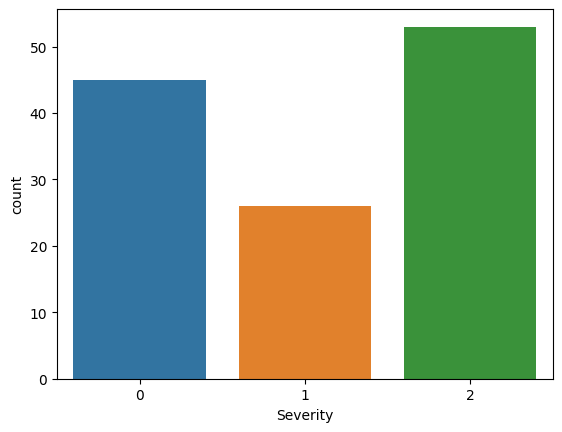

In [13]:
sns.countplot(x=y)

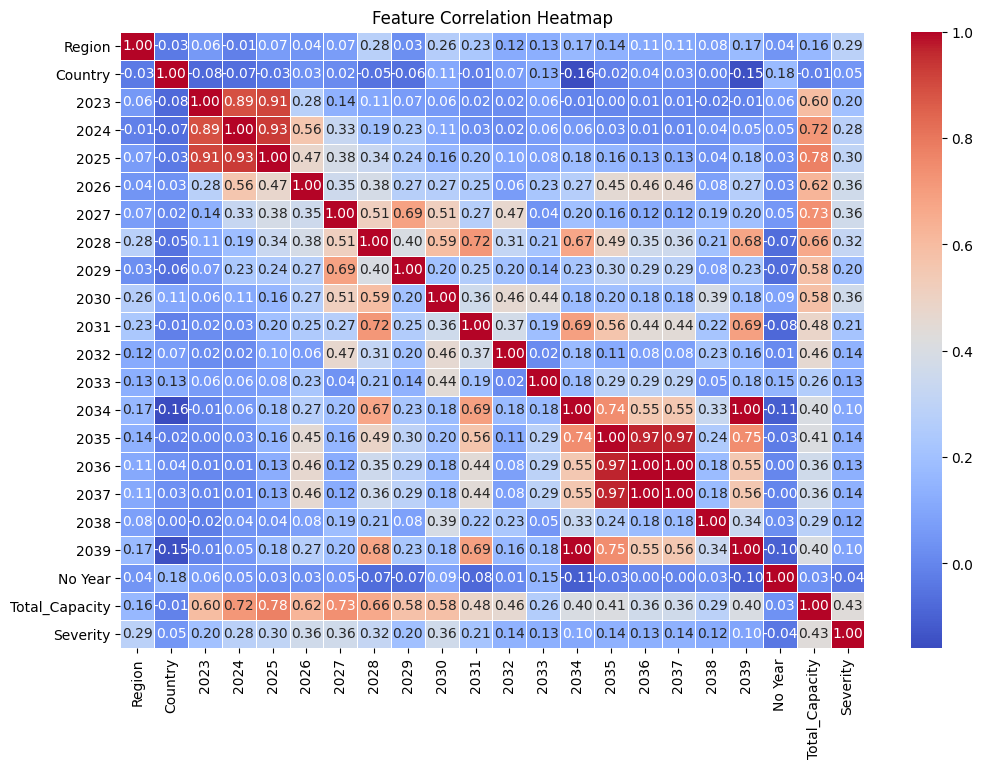

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Show the heatmap
plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42 )

In [16]:
labels=['Severe','mild','Moderate']

In [17]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

Using TensorFlow backend.


<AxesSubplot:xlabel='Severity', ylabel='count'>

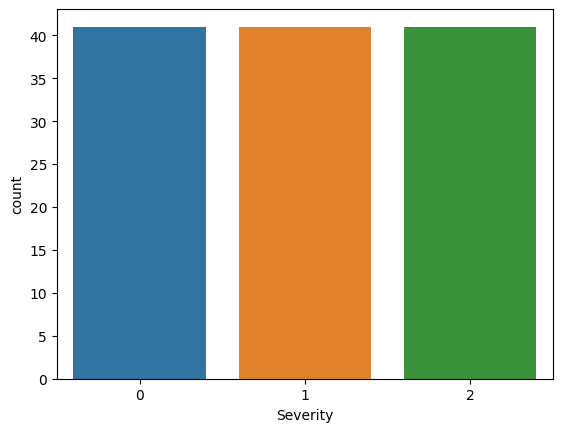

In [18]:
sns.countplot(x=y_train_resampled)

In [19]:
#defining global variables to store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [20]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, testY,predict):
    testY = testY.astype('int')
    predict = predict.astype('int')
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100 
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+' Accuracy    : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FSCORE      : '+str(f))
    report=classification_report(predict, testY,target_names=labels)
    print('\n',algorithm+" classification report\n",report)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="Blues" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()

# Naives Bayes

Model loaded successfully.
NaiveBayesClassifier Accuracy    : 92.0
NaiveBayesClassifier Precision   : 93.5185185185185
NaiveBayesClassifier Recall      : 88.88888888888889
NaiveBayesClassifier FSCORE      : 89.92327365728899

 NaiveBayesClassifier classification report
               precision    recall  f1-score   support

      Severe       1.00      0.89      0.94         9
        mild       0.67      1.00      0.80         4
    Moderate       1.00      0.92      0.96        12

    accuracy                           0.92        25
   macro avg       0.89      0.94      0.90        25
weighted avg       0.95      0.92      0.93        25



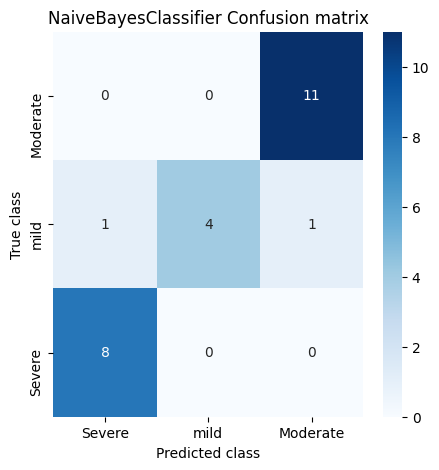

In [21]:
from sklearn.naive_bayes import GaussianNB
import joblib
import os

# Check if model exists
if os.path.exists('model/NaiveBayesClassifier.pkl'):
    # Load the trained model
    NB = joblib.load('model/NaiveBayesClassifier.pkl')
    print("Model loaded successfully.")
else:
    # Train the model (assuming X_train and y_train are defined)
    NB = GaussianNB()
    NB.fit(X_train, y_train)
    
    # Save the trained model
    os.makedirs('model', exist_ok=True)  # Ensure 'model' directory exists
    joblib.dump(NB, 'model/NaiveBayesClassifier.pkl')
    print("Model saved successfully.")

# Predictions and Evaluation
predict = NB.predict(X_test)
calculateMetrics("NaiveBayesClassifier", predict, y_test)


# KNN

Model loaded successfully.
KNeighborsClassifier Accuracy    : 96.0
KNeighborsClassifier Precision   : 91.66666666666666
KNeighborsClassifier Recall      : 96.66666666666667
KNeighborsClassifier FSCORE      : 93.48370927318295

 KNeighborsClassifier classification report
               precision    recall  f1-score   support

      Severe       0.90      1.00      0.95         9
        mild       1.00      0.75      0.86         4
    Moderate       1.00      1.00      1.00        12

    accuracy                           0.96        25
   macro avg       0.97      0.92      0.93        25
weighted avg       0.96      0.96      0.96        25



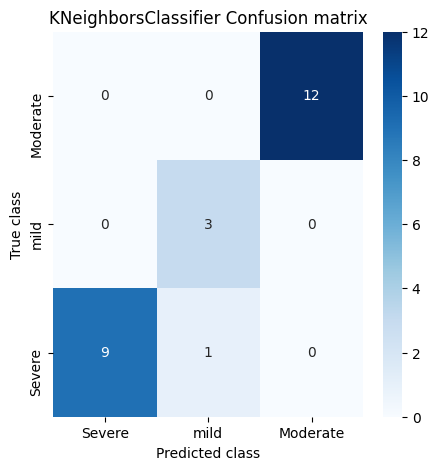

In [22]:
from sklearn.neighbors import KNeighborsClassifier
import joblib
import os

# Check if model exists
if os.path.exists('model/KNeighborsClassifier.pkl'):
    # Load the trained model
    KNN = joblib.load('model/KNeighborsClassifier.pkl')
    print("Model loaded successfully.")
else:
    # Train the model (assuming X_train and y_train are defined)
    KNN = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    KNN.fit(X_train, y_train)
    
    # Save the trained model
    os.makedirs('model', exist_ok=True)  # Ensure 'model' directory exists
    joblib.dump(KNN, 'model/KNeighborsClassifier.pkl')
    print("Model saved successfully.")

# Predictions and Evaluation
predict = KNN.predict(X_test)
calculateMetrics("KNeighborsClassifier", predict, y_test)


In [23]:
test=pd.read_csv(r'testdata.csv')
test

,Unnamed: 0,Region,Country,2023,2024,2025,2026,2027,2028,2029,...,2033,2034,2035,2036,2037,2038,2039,No Year,Total_Capacity,Severity
0,35,1,23,151,50,51,51,0,0,0,...,0,0,0,0,0,0,0,89,354,1
1,121,3,123,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,84,0,0
2,79,2,117,0,1000,600,0,1500,0,0,...,0,0,0,0,0,0,0,0,3100,2
3,100,3,54,180,200,108,2800,1760,0,0,...,0,0,0,0,0,0,0,53,5048,2
4,49,2,5,0,0,241,0,0,0,0,...,0,0,0,0,0,0,0,0,241,1
5,111,3,90,0,48,988,0,0,0,0,...,0,0,0,0,0,0,0,59,1036,2
6,119,3,112,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,88,0,0
7,115,3,98,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,63,0,0
8,84,3,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,37,0,0
9,118,3,105,14,21,43,129,50,0,0,...,0,0,0,0,0,0,0,81,257,1


In [24]:
test = df.drop(['Severity'],axis=1)

In [25]:
predict=KNN.predict(test)
predict

array([2, 0, 0, 1, 0, 2, 1, 0, 1, 0, 0, 1, 0, 2, 1, 0, 1, 0, 0, 2, 0, 1,
       2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 2, 2, 0, 1, 1, 2, 0, 0, 1, 2, 2, 1, 0, 1, 2, 2, 1, 0, 2, 0,
       1, 2, 2, 1, 2, 2, 0, 2, 1, 2, 1, 2, 0, 2, 2, 0, 0, 0, 0, 2, 1, 2,
       1, 0, 2, 2, 1, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 2, 1, 2, 2,
       2, 2, 2, 2, 0, 0, 2, 2, 1, 0, 2, 0, 2, 2])

In [26]:
df['prediction'] =[labels[i] for i in predict]
df

,Region,Country,2023,2024,2025,2026,2027,2028,2029,2030,...,2034,2035,2036,2037,2038,2039,No Year,Total_Capacity,Severity,prediction
0,0,1,0,114,0,0,0,52,88,48,...,42,36,44,100,0,0,16,586,2,Moderate
1,0,15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,18,0,0,Severe
2,0,16,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,61,0,0,Severe
3,0,18,0,0,100,0,0,0,0,0,...,0,0,0,0,0,0,0,100,1,mild
4,0,27,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,67,0,0,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,3,112,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,88,0,0,Severe
120,3,114,2834,2594,1613,2540,792,1756,2300,12000,...,0,0,0,0,0,0,92,31277,2,Moderate
121,3,123,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,84,0,0,Severe
122,4,3,337,2328,5049,6251,6269,9800,7468,5945,...,2420,1470,4010,1558,3638,1306,6,71691,2,Moderate
